# Практическое задание № 1. Классификация


**Работу выполнил:**

Сухов Николай Михайлович, id: 368876

# Распознавание активности человека на основе данных с мобильных сенсоров

Необходимо по данным с мобильных сенсоров при помощи прикладных алгоритмов машинного обучения предсказать активность человека по шести классам движений:
* Движется по прямой
* Движется вверх (например, движение по лестнице вверх)
* Движется вниз (например, движение по лестнице вниз)
* Сидит
* Стоит
* Лежит

## Сведения о наборе данных
Набор данных содержит записи датчиков со сматфонов (акселерометр и гироскоп с частотой дискретизации 50 Гц) от 30 участников, выполняющих следующие действия: ходьба, ходьба по лестнице, ходьба по лестнице, сидение, стояние и лежание. Данные были предварительно обработаны при помощи фильтров шума. Набор данных представлен Хорхе Л. Рейес-Ортисом.

Признаки были извлечены из 3-х осевых необработанных сигналов акселерометра и гироскопа tAcc-XYZ и tGyro-XYZ. Эти сигналы были сняты с постоянной частотой 50 Гц. Затем были отфильтрованны с помощью медианного фильтра и низкочастотного фильтра Баттерворта 3-го порядка с частотой 20 Гц для удаления шумов. Аналогичным образом сигнал ускорения был разделен на сигналы ускорения тела и гравитации (`tBodyAcc-XYZ` и `tGravityAcc-XYZ`) с помощью другого низкочастотного фильтра Баттерворта с угловой частотой 0,3 Гц. Линейное ускорение тела и угловая скорость были использованы для получения сигналов "рывка" — (`tBodyAccJerk-XYZ` и `tBodyGyroJerk-XYZ`). Также величина этих трехмерных сигналов была расчитана с использованием евклидовой нормы — (`tBodyAccMag`, `tGravityAccMag`, `tBodyAccJerkMag`, `tBodyGyroMag`, `tBodyGyroJerkMag`). 

Наконец, к некоторым из этих сигналов было применено быстрое преобразование Фурье (БПФ), в результате чего получились `fBodyAcc-XYZ`, `fBodyAccJerk-XYZ`, `fBodyGyro-XYZ`, `fBodyAccJerkMag`, `fBodyGyroMag`, `fBodyGyroJerkMag`. (Обратите внимание на "f" для обозначения сигналов в частотной области). 

Набор переменных, которые были оценены по этим сигналам, следующий: 
* mean(): Среднее значение
* std(): Стандартное отклонение
* mad(): Среднее абсолютное отклонение 
* max(): Наибольшее значение в массиве
* min(): Наименьшее значение в массиве
* sma(): Область величины сигнала
* energy(): Мера энергии. Сумма квадратов, деленная на количество значений. 
* iqr(): Интерквартильный размах 
* entropy(): Энтропия сигнала
* arCoeff(): Коэффициенты авторегрессии с порядком Burg, равным 4
* correlation(): коэффициент корреляции между двумя сигналами
* maxInds(): индекс частотной составляющей с наибольшей величиной
* meanFreq(): средневзвешенное значение частотных компонент для получения средней частоты
* skewness(): перекос сигнала в частотной области 
* kurtosis(): эксцесс сигнала в частотной области 
* bandsEnergy(): Энергия частотного интервала в пределах 64 бинов БПФ каждого окна.
* angle(): Угол между векторами.
## Импорт библиотек
Первым делом импортируем необходимые библиотеки для работы с данными:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV

## Считываем набор данных

В прикладных задачах машинного обучения очень важен процесс извлечения признаков (feature extraction), в ходе которого данные интерпретируются в информативные признаки. Также этот процесс может называться проектирование признаков (feature engineering), это весьма трудоемкая и творческая задача. В рамках работы мы опустим эту часть и воспользуемся предобработанными данными. 

In [2]:
df = pd.read_csv('train.csv')
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


Теперь, загрузим полный набор данных и сохранить его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели

In [3]:
def load_dataset(label_dict):
    train_X = pd.read_csv('train.csv').values[:,:-2]
    train_y = pd.read_csv('train.csv')['Activity']
    train_y = train_y.map(label_dict).values
    test_X = pd.read_csv('test.csv').values[:,:-2]
    test_y = pd.read_csv('test.csv')
    test_y = test_y['Activity'].map(label_dict).values
    return(train_X, train_y, test_X, test_y)
label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}
train_X, train_y, test_X, test_y = load_dataset(label_dict)

## Выбор модели

Импортируйте выбранную вами модель из библиотеки `sklearn` и инициализируйте её в объект `model`:

Также необходимо выбрать **несколько** моделей ML для сравнения полученных результатов.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Инициализируем несколько моделей для сравнения
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

## Мотивация выбора моделей


### Decision Tree

#### Преимущества для данной задачи:
- **Нет предположений о распределении данных**
- **Прямая оценка важности признаков**

#### Ключевые гиперпараметры:
- **max_depth**: Максимальная глубина дерева
  -  Делает структуру модели более сложной, повышается риск переобучения, вместе с точностью предсказаний
- **min_samples_split**: Минимальное количество сэмплов для разделения узла
  -  Уменьшает сложность модели, скорость обучения, повышает риск переобучения
- **min_samples_leaf**: Минимальное количество сэмплов в листе
  -  Уменьшает переобучение

### Random Forest

#### Преимущества для нашей задачи:
- **Хорошо работает с высокоразмерными данными** - датасет содержит 561 признак
- **Устойчив к переобучению** благодаря бэггингу и случайному выбору признаков
- **Улавливает нелинейные зависимости** между сигналами сенсоров и активностью

#### Ключевые гиперпараметры:
- **n_estimators**: Количество деревьев в лесу
  -  Увеличивает стабильность, уменьшает шанс переобучения
- **max_depth**: Максимальная глубина деревьев
  -  Делает структуру модели более сложной, повышается риск переобучения, вместе с точностью предсказаний
- **min_samples_split**: Минимальное количество сэмплов для разделения узла
  -  Уменьшает сложность модели, скорость обучения, повышает риск переобучения
- **min_samples_leaf**: Минимальное количество сэмплов в листе
  -  Уменьшает переобучение

### Logistic Regression

#### Преимущества для данной задачи:
- **Простая и интерпретируемая модель** - легко понять вклад каждого признака
- **Быстрое обучение**
- **Естественно поддерживает многоклассовую классификацию**

#### Ключевые гиперпараметры:
- **C**: Обратный параметр регуляризации
  -  Уменьшает регуляризацию,  сложность модели
- **penalty**: Тип регуляризации
  - none: Без регуляризации
  - l1: Lasso регуляризация - отбор признаков
  - l2: Ridge регуляризация - уменьшение весов
  - elasticnet: Комбинация L1 и L2
- **solver**: Алгоритм оптимизации
  - lbfgs: Рекомендуется для большинства случаев
  - liblinear: Для маленьких датасетов
  - saga: Для больших датасетов

### K-Nearest Neighbors

#### Преимущества для данной задачи:
- **Нет предположений о распределении данных**
- **Прост в понимании и интерпретации**
- **Хорошо улавливает локальные закономерности** в данных сенсоров

#### Ключевые гиперпараметры:
- **n_neighbors**: Количество соседей
  -  Увеличивает сглаживание границ между классами
- **weights**: Весовая функция для соседей
  - uniform: Все соседи имеют одинаковый вес
  - distance: Близкие соседи имеют больший вес
- **metric**: Метрика расстояния
  - euclidean: Евклидово расстояние
  - manhattan: Манхэттенское расстояние
  - cosine: Косинусное расстояние

## Обучение и оценка модели

Обучим модель, используя признаки из обучающего набора (`train_X`) и метки в качестве базовой истины (`train_y`).

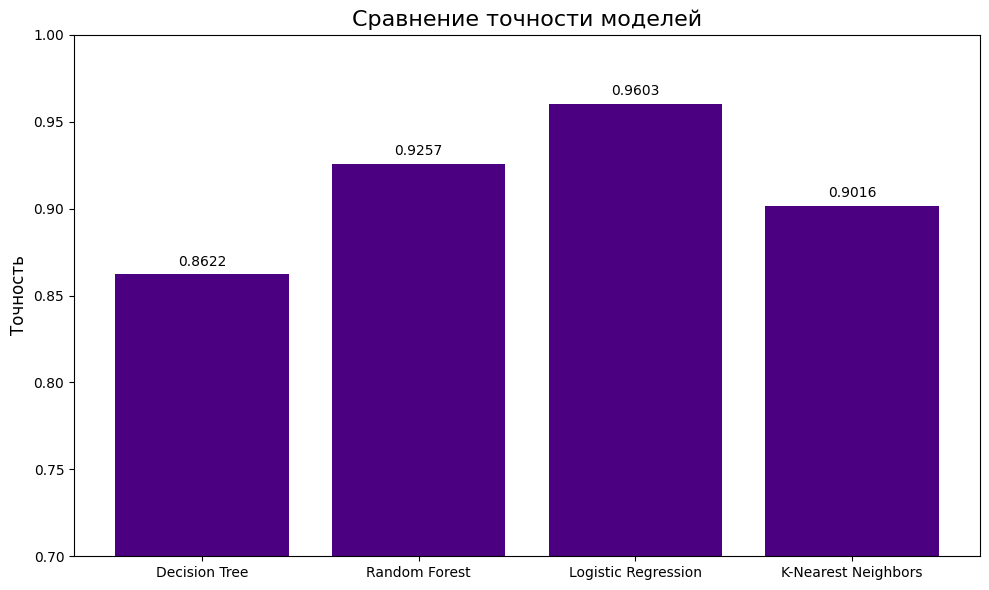

In [ ]:
results = {}

for name, model in models.items():
    model.fit(train_X, train_y)
    yhat = model.predict(test_X)
    results[name] = {
        'model': model,
        'predictions': yhat,
        'accuracy': np.mean(yhat == test_y)
    }

accuracies = [results[name]['accuracy'] for name in models.keys()]
model_names = list(models.keys())

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color="Indigo")
plt.title('Сравнение точности моделей', fontsize=16)
plt.ylabel('Точность', fontsize=12)
plt.xticks()
plt.ylim(0.7, 1.0)

for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
        f'{accuracy:.4f}', ha='center')

plt.tight_layout()
plt.show()

Выберем лучшую модель, выведем ```clasification_report``` и матрицу ошибок

Лучшая модель: Logistic Regression
Точность: 0.9603
Отчёт классификации:
                    precision    recall  f1-score   support

           Walking       0.94      0.99      0.97       496
  Walking Upstairs       0.97      0.94      0.95       471
Walking Downstairs       0.99      0.96      0.98       420
           Sitting       0.98      0.88      0.93       491
          Standing       0.90      0.98      0.94       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



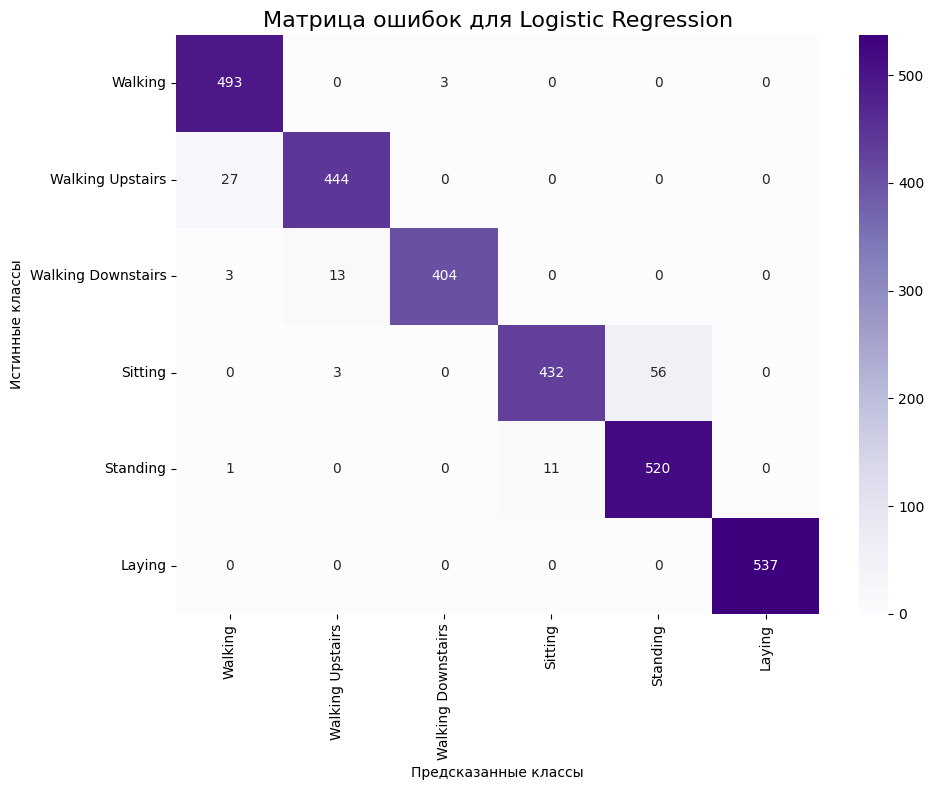

In [ ]:
best_model_name = max(results, key=lambda x: results[x]['accuracy'])

print(f"Лучшая модель: {best_model_name}")
print(f"Точность: {results[best_model_name]['accuracy']:.4f}")

target_names = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
print("Отчёт классификации:")
print(classification_report(test_y, results[best_model_name]['predictions'], target_names=target_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_y, results[best_model_name]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Матрица ошибок для {best_model_name}', fontsize=16)
plt.xlabel('Предсказанные классы')
plt.ylabel('Истинные классы')
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.show()

# АНАЛИЗ ГОВНА ВЫШЕ ДОПИСАТЬ СЮДА

In [ ]:
# Пример настройки гиперпараметров для Random Forest
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search.fit(train_X, train_y)
    
    print("Лучшие параметры:", grid_search.best_params_)
    print("Лучшая точность:", grid_search.best_score_)
    
    # Обновляем лучшую модель
    best_model = grid_search.best_estimator_
    best_predictions = best_model.predict(test_X)
    improved_accuracy = np.mean(best_predictions == test_y)
    print(f"Точность на тестовых данных после настройки: {improved_accuracy:.4f}")

ФИНАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ
Decision Tree            : 0.8622
Random Forest            : 0.9257
Logistic Regression      : 0.9603
K-Nearest Neighbors      : 0.9016

            АНАЛ                ИЗ ПРОБЛЕМНЫХ КЛАССОВ:
Walking             : Точность = 0.9940
Walking Upstairs    : Точность = 0.9427
Walking Downstairs  : Точность = 0.9619
Sitting             : Точность = 0.8798
Standing            : Точность = 0.9774
Laying              : Точность = 1.0000


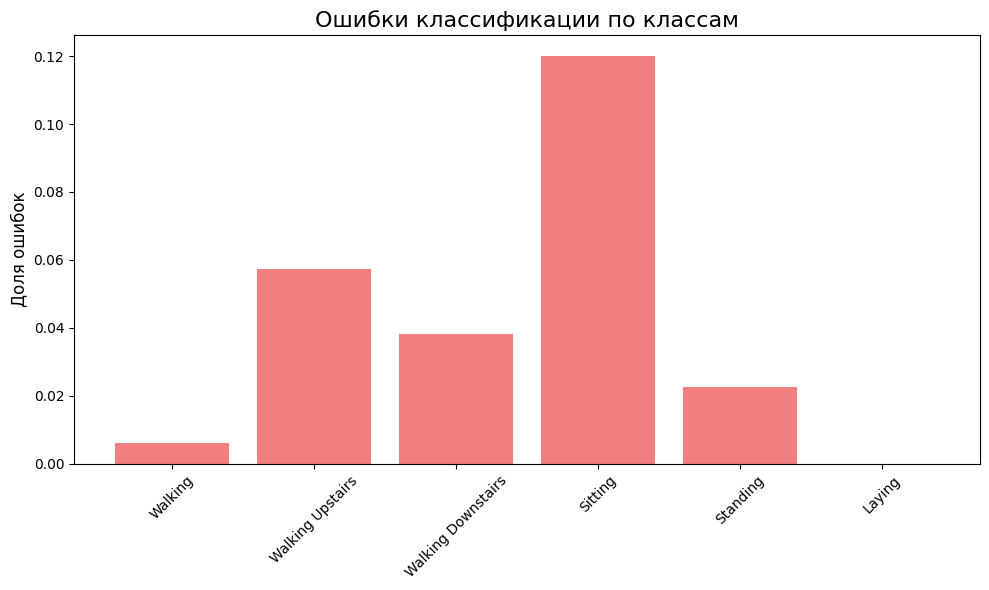

In [ ]:
# Финальное сравнение всех моделей
print("ФИНАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
for name in models.keys():
    accuracy = results[name]['accuracy']
    print(f"{name:<25}: {accuracy:.4f}")

# Анализ наиболее проблемных классов
print("\n            АНАЛ                ИЗ ПРОБЛЕМНЫХ КЛАССОВ:")
class_errors = {}
for i, class_name in enumerate(target_names):
    class_mask = test_y == i
    class_accuracy = np.mean(best_predictions[class_mask] == test_y[class_mask])
    class_errors[class_name] = 1 - class_accuracy
    print(f"{class_name:<20}: Точность = {class_accuracy:.4f}")

# Визуализация ошибок по классам
plt.figure(figsize=(10, 6))
plt.bar(class_errors.keys(), class_errors.values(), color='lightcoral')
plt.title('Ошибки классификации по классам', fontsize=16)
plt.ylabel('Доля ошибок', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




## Задание


Выведите отчет о классификации, сравнив предсказания (`yhat`) с базовой истиной (`test_y`).

В чем разница между показателями `precision` и `recall`? Что такое показатель `F1`?

Используйте вариации нескольких моделей с разными гиперпараметрами. Сравните полученный результат (визуализируйте полученный результат).

Что такое гиперпараметры модели машинного обучения (МО)?

Опишите влияние гиперпараметров в выбранных вами моделях МО.